# Microwave-optical transduction fidelity

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

from src import *
from src.params import *
from src.plots import *

# Enable SVG in Jupyter notebooks.
%config InlineBackend.figure_formats = ['svg']

### Parameters

In [2]:
# Rochman et al. device, extracavity transduction.
params = ROCHMAN_PARAMS

# Ideal out-coupling (eta_a = eta_b = 1) isolates the parasitic squeezing;
# False uses the measured values, which scale the efficiency by eta_a eta_b.
IDEAL_COUPLING = True

# Optical drive detuning Delta_a [2*pi GHz].
DELTA_A_LIST = [0.1, 0.5, 1.0]

n_fock = np.arange(0, 11)               # Number states.
nbar   = np.linspace(0.25, 10.0,31)    # Coherent / GKP states.

N_JOBS = -1                             # Parallel workers for the fidelity sweeps.

### Numerics

In [3]:
def gkp_state_fidelity(nbar, moments):
    """
    Transduced GKP |0> state fidelity, auto-sized grid (App. F1).
    """
    return fidelity(lambda w: Phi_gkp(w, nbar), *moments, *integration_grid('gkp', nbar))


def gkp_avg_gate_infidelity(nbar, moments, trunc=16):
    """
    Numeric GKP average gate infidelity 1 - Fbar, the same quantity as the
    analytic App. F2 formula. From the decoded Pauli-transfer-matrix diagonal:
    lambda_z from the transduced |0>_Z; lambda_x from the same decode of the
    90-degree phase-space-rotated state Phi_gkp(-i z) (an X eigenstate for the
    square lattice); lambda_y = lambda_x lambda_z for the independent-quadrature
    Gaussian channel. Then Fbar = (3 + lambda_x + lambda_y + lambda_z) / 6.
    """
    lam_z = decoded_pauli(lambda w: Phi_out(w, lambda v: Phi_gkp(v, nbar, mu=0), *moments), trunc)[2]
    lam_x = decoded_pauli(lambda w: Phi_out(w, lambda v: Phi_gkp(-1j*v, nbar, mu=0), *moments), trunc)[0]
    lam_y = lam_x * lam_z
    return 1 - (3 + lam_x + lam_y + lam_z) / 6

In [4]:
# Base transducer parameters and derived quantities.
base = {**params, 'eta_a': 1.0, 'eta_b': 1.0} if IDEAL_COUPLING else dict(params)
omega_b = base['omega_b']
g_t = np.sqrt(base['kappa_a'] * base['kappa_b']) / 2 

results = {}
for Delta_a in DELTA_A_LIST:
    z = 1 / abs(1 - (omega_b / Delta_a)**2)               # parasitic ratio z = |g_bp/g_bs|
    transducer = Transducer.from_params(base, Delta=omega_b)
    moments = aout_moments(*transducer.channel(omega_b, g_t, z * g_t))
    S_12, S_14, expect_NdN, *_ = moments

    # State fidelity.
    F_fock = np.array(
        [fidelity(lambda w: Phi_fock(w, n), *moments, *integration_grid('fock', n)) for n in n_fock]
        )
    F_coh = np.array(
        [fidelity(lambda w: Phi_coherent(w, np.sqrt(nb)), *moments, *integration_grid('coherent', nb)) for nb in nbar]
        )
    F_gkp = np.array(
        Parallel(n_jobs=N_JOBS)(delayed(gkp_state_fidelity)(nb, moments) for nb in nbar)
        )

    # GKP average gate infidelity: numeric decode (App. F3) and analytic form (App. F2).
    chan = gkp_channel_params(base['kappa_a'], base['kappa_b'], omega_b, z, base['eta_a'], base['eta_b'])
    L_gate = np.array(
        Parallel(n_jobs=N_JOBS)(delayed(gkp_avg_gate_infidelity)(nb, moments) for nb in nbar)
        )
    L_ana = np.array([gkp_infidelity(nb, *chan) for nb in nbar])

    # Store results for the current Delta_a. eta_overshoot = |S_12|^2 - 1 is the
    # parasitic gain on the transduced signal (Eq. eta-meas), ~z^2/2 at ideal
    # coupling -- quoted in the text, no longer plotted.
    results[Delta_a] = dict(
        z = z,
        eta_overshoot = abs(S_12)**2 - 1,
        F_fock = F_fock,
        F_coh = F_coh,
        F_gkp = F_gkp,
        L_gate = L_gate,
        L_ana = L_ana
        )

### State fidelity

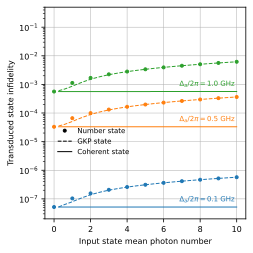

In [5]:
# State infidelity vs input photon number, one colour per drive detuning Delta_a.
fig, ax = plt.subplots(
    figsize = (FIG_SIZES['onecol'], 1 * FIG_SIZES['onecol']),
    layout = 'constrained',
    )

colors = dict(zip(DELTA_A_LIST, ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']))
number_kw, coherent_kw, gkp_kw = dict(marker='o', ms=3, ls=''), dict(ls='-'), dict(ls='--')

y = lambda F: np.abs(1 - F)

for Delta_a, r in results.items():
    c = colors[Delta_a]
    ax.plot(n_fock, y(r['F_fock']), color=c, **number_kw)
    ax.plot(nbar,   y(r['F_coh']),  color=c, **coherent_kw)
    ax.plot(nbar,   y(r['F_gkp']),  color=c, **gkp_kw)
    ax.annotate(
        f"$\\Delta_a/2\\pi = {Delta_a:.1f}$ GHz",
        xy = (nbar[-1], y(r['F_coh'])[-1]),
        xytext = (-2, 4), textcoords = 'offset points',
        color = c, ha = 'right', va = 'bottom',
        )
    ax.set_ylim(2e-8, 5e-1)

state_handles = [
    plt.Line2D([], [], color='k', label=lbl, **kw) for lbl, kw in
    [('Number state', number_kw), ('GKP state', gkp_kw), ('Coherent state', coherent_kw)]
    ]
ax.legend(handles=state_handles, loc=(0.05, 0.285), frameon=False)

ax.set(
    xlabel = 'Input state mean photon number',
    ylabel = 'Transduced state infidelity',
    yscale = 'log',
    xlim = (-0.5, 10.5),
    )
ax.grid('both')

fig.savefig('fig/transduction.pdf', bbox_inches='tight')

### Average gate fidelity

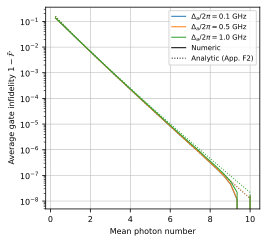

In [6]:
# GKP average gate infidelity vs mean photon number:
# solid = numeric (decoded Pauli-transfer-matrix diagonal), dotted = analytic (App. F2).
fig, ax = plt.subplots(figsize=(1.1 * FIG_SIZES['onecol'], FIG_SIZES['onecol']))

for Delta_a, r in results.items():
    c = colors[Delta_a]
    ax.plot(nbar, r['L_gate'], color=c, ls='-',
            label=f"$\\Delta_a/2\\pi = {Delta_a:.1f}$ GHz")
    ax.plot(nbar, r['L_ana'], color=c, ls=':')

ax.plot([], [], 'k', ls='-', label='Numeric')
ax.plot([], [], 'k', ls=':', label='Analytic (App. F2)')

ax.set(xlabel='Mean photon number', ylabel=r'Average gate infidelity $1 - \bar{\mathcal{F}}$',
       yscale='log')
ax.grid('both')
ax.legend()

fig.tight_layout()
fig.savefig('fig/transduction_logical.pdf', bbox_inches='tight')